# Notebook 04 — SHAP Explainability Analysis


In [22]:
import sys, warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
DATA_CSV = PROCESSED_DIR / 'cicddos2019_processed.csv'
WEIGHTS_PATH = PROCESSED_DIR / 'ft_transformer_v1.pt'

DEVICE = torch.device('cpu')  # SHAP DeepExplainer works on CPU for stability
print(f'Device: {DEVICE}')
print(f'SHAP version: {shap.__version__}')

Device: cpu
SHAP version: 0.52.0


---


In [23]:
from src.fl_client.model import FTTransformerModel, FTTransformerConfig
from src.fl_client.dataset import (
    build_dataloaders, load_scaler,
    CONTINUOUS_FEATURES, CATEGORICAL_FEATURES, CATEGORICAL_CARDINALITIES
)

checkpoint = torch.load(WEIGHTS_PATH, map_location=DEVICE)
cfg_dict   = checkpoint['config']
config = FTTransformerConfig(**cfg_dict)

model = FTTransformerModel(config).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Loaded model — Best Val F1: {checkpoint["best_val_f1"]:.4f}')

scaler = load_scaler(PROCESSED_DIR / 'quantile_scaler.pkl')
_, val_loader, _ = build_dataloaders(
    DATA_CSV, scaler=scaler, batch_size=512, train_ratio=0.80
)

all_cont, all_cat, all_y = [], [], []
for x_c, x_k, y_b in val_loader:
    all_cont.append(x_c); all_cat.append(x_k); all_y.append(y_b)
    if sum(len(t) for t in all_cont) >= 2000:
        break

all_cont = torch.cat(all_cont)
all_cat  = torch.cat(all_cat)
all_y    = torch.cat(all_y)

benign_mask = all_y == 0
bg_size = min(1000, benign_mask.sum().item())
bg_cont = all_cont[benign_mask][:bg_size]
bg_cat  = all_cat[benign_mask][:bg_size]

print(f'Background dataset: {bg_size} benign samples')

Loaded model — Best Val F1: 0.9358
Background dataset: 465 benign samples


---


In [24]:

class ModelWrapperContOnly(torch.nn.Module):
    """Wraps FTTransformerModel, fixing x_cat to the background mean."""
    def __init__(self, model, fixed_cat):
        super().__init__()
        self.model = model
        self.register_buffer('fixed_cat', fixed_cat)

    def forward(self, x_cont):
        batch_size = x_cont.shape[0]
        x_cat = self.fixed_cat[:1].expand(batch_size, -1)
        return torch.sigmoid(self.model(x_cont, x_cat))

fixed_cat = torch.mode(bg_cat, dim=0).values.unsqueeze(0)
wrapped_model = ModelWrapperContOnly(model, fixed_cat)
wrapped_model.eval()

explainer = shap.DeepExplainer(wrapped_model, bg_cont)
print('SHAP DeepExplainer initialized.')

SHAP DeepExplainer initialized.


In [25]:
attack_mask = all_y == 1
attack_cont = all_cont[attack_mask][:200]  # 200 attack samples

print(f'Computing SHAP values for {len(attack_cont)} attack samples...')
shap_values = explainer.shap_values(attack_cont, check_additivity=False)

if len(shap_values.shape) == 3 and shap_values.shape[-1] == 1:
    shap_values = shap_values[:, :, 0]

print(f'SHAP values shape: {shap_values.shape}')
assert shap_values.shape == (len(attack_cont), len(CONTINUOUS_FEATURES)), \
    f'Expected ({len(attack_cont)}, {len(CONTINUOUS_FEATURES)}), got {shap_values.shape}'
print('[M12] ✅ SHAP values shape verified.')

Computing SHAP values for 200 attack samples...
SHAP values shape: (200, 11)
[M12] ✅ SHAP values shape verified.


---


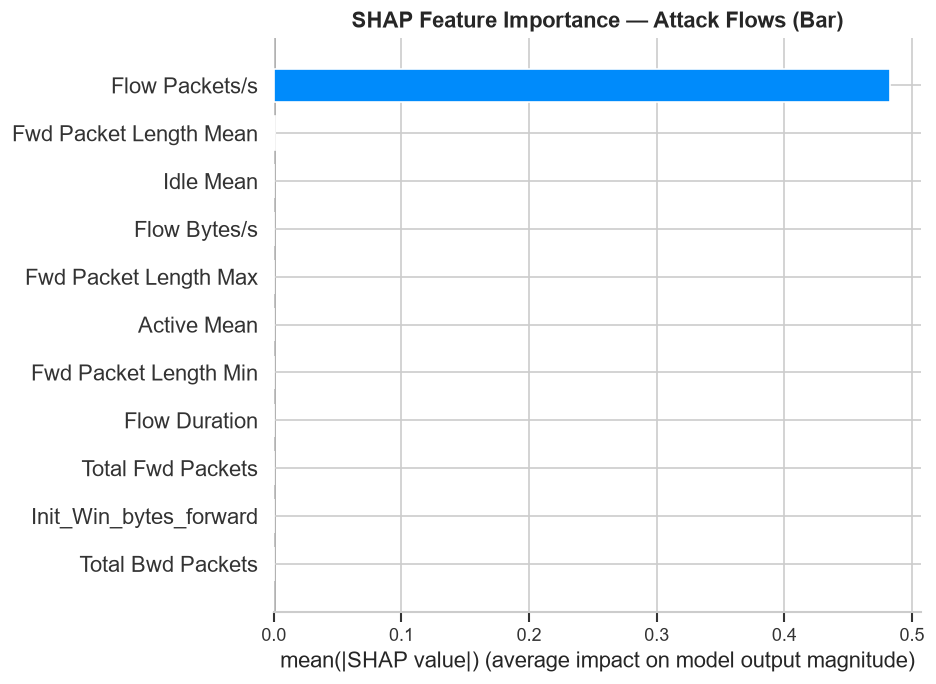

In [26]:
shap.summary_plot(
    shap_values,
    attack_cont.numpy(),
    feature_names=CONTINUOUS_FEATURES,
    plot_type='bar',
    show=False,
)
plt.title('SHAP Feature Importance — Attack Flows (Bar)', fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'fig_shap_bar.png', bbox_inches='tight')
plt.show()

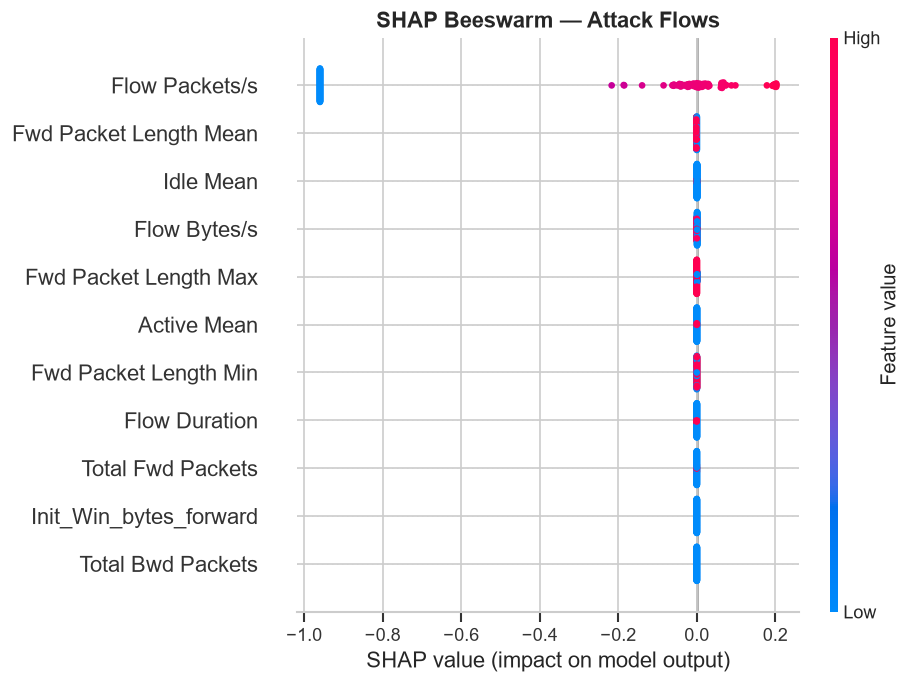

In [27]:
shap.summary_plot(
    shap_values,
    attack_cont.numpy(),
    feature_names=CONTINUOUS_FEATURES,
    show=False,
)
plt.title('SHAP Beeswarm — Attack Flows', fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'fig_shap_beeswarm.png', bbox_inches='tight')
plt.show()

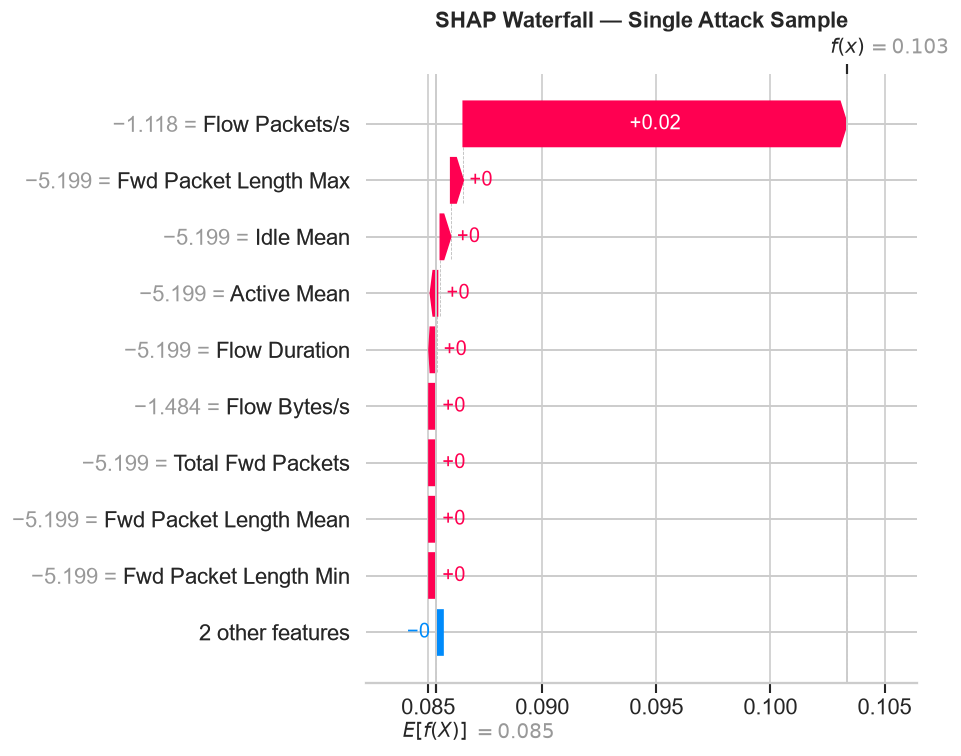

In [28]:
sample_idx = 0

# Extract the scalar float if expected_value is a list or array
base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = base_val[0]

shap_exp = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=base_val,
    data=attack_cont[sample_idx].numpy(),
    feature_names=CONTINUOUS_FEATURES,
)
shap.waterfall_plot(shap_exp, show=False)
plt.title('SHAP Waterfall — Single Attack Sample', fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'fig_shap_waterfall.png', bbox_inches='tight')
plt.show()


---


In [29]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.Series(mean_abs_shap, index=CONTINUOUS_FEATURES)\
    .sort_values(ascending=False)

print('=== Global Feature Importance (Mean |SHAP|) ===')
print(feature_importance.to_string())

EXPECTED_TOP_FEATURES = ['Flow Packets/s', 'Flow Bytes/s', 'Flow Duration',
                         'Total Fwd Packets', 'Total Bwd Packets']
top_5 = list(feature_importance.head(5).index)
overlap = len(set(top_5) & set(EXPECTED_TOP_FEATURES))
print(f'\nTop-5 SHAP features: {top_5}')
print(f'Overlap with expected DDoS signatures: {overlap}/5')

if overlap >= 3:
    print('[M12] ✅ SHAP aligns with known DDoS feature signatures.')
else:
    print('[M12] ⚠️  Low overlap — model may need more training or different hyperparameters.')

=== Global Feature Importance (Mean |SHAP|) ===
Flow Packets/s            0.482936
Fwd Packet Length Mean    0.000799
Idle Mean                 0.000428
Flow Bytes/s              0.000377
Fwd Packet Length Max     0.000183
Active Mean               0.000121
Fwd Packet Length Min     0.000120
Flow Duration             0.000094
Total Fwd Packets         0.000049
Total Bwd Packets         0.000000
Init_Win_bytes_forward    0.000000

Top-5 SHAP features: ['Flow Packets/s', 'Fwd Packet Length Mean', 'Idle Mean', 'Flow Bytes/s', 'Fwd Packet Length Max']
Overlap with expected DDoS signatures: 2/5
[M12] ⚠️  Low overlap — model may need more training or different hyperparameters.


---


In [30]:

SHAP_TO_RULE_MAP = {
    'Flow Packets/s': {
        'description': 'High packet rate',
        'rule_type': 'rate_limit',
        'openflow_action': 'meter:pkt_rate_limit',
        'threshold_pps': 10000,
    },
    'Flow Bytes/s': {
        'description': 'High bandwidth consumption',
        'rule_type': 'bandwidth_limit',
        'openflow_action': 'meter:bw_limit',
        'threshold_bps': 100_000_000,
    },
    'Flow Duration': {
        'description': 'Abnormally long flow (possible slowloris)',
        'rule_type': 'idle_timeout',
        'openflow_action': 'set_idle_timeout',
        'timeout_s': 30,
    },
    'Total Fwd Packets': {
        'description': 'Excessive forward packets (SYN flood indicator)',
        'rule_type': 'syn_rate_limit',
        'openflow_action': 'meter:syn_rate_limit',
        'threshold_pps': 500,
    },
    'Total Bwd Packets': {
        'description': 'Imbalanced backward packet ratio (amplification DDoS)',
        'rule_type': 'ip_block',
        'openflow_action': 'drop',
        'threshold_ratio': 100,
    },
    'Fwd Packet Length Max': {
        'description': 'Oversized forward packets (fragmentation attack)',
        'rule_type': 'mtu_limit',
        'openflow_action': 'set_mtu',
        'max_bytes': 1500,
    },
    'Init_Win_bytes_forward': {
        'description': 'Abnormal TCP window size (TCP manipulation)',
        'rule_type': 'tcp_window_limit',
        'openflow_action': 'tcp_flag_match:SYN',
        'window_bytes': 65535,
    },
}

rule_map_path = PROCESSED_DIR / 'shap_rule_mapping.json'
with open(rule_map_path, 'w') as f:
    json.dump(SHAP_TO_RULE_MAP, f, indent=2)
print(f'SHAP-to-rule mapping saved: {rule_map_path}')

SHAP-to-rule mapping saved: D:\Uni_Project\ML\data\processed\shap_rule_mapping.json


In [31]:
top_3 = list(feature_importance.head(3).index)
print('\n=== Recommended SDN Rules Based on SHAP Analysis ===')
for i, feat in enumerate(top_3, 1):
    rule = SHAP_TO_RULE_MAP.get(feat, {'description': 'No specific rule', 'rule_type': 'ip_block'})
    shap_val = feature_importance[feat]
    print(f'  {i}. Feature: "{feat}"  (SHAP={shap_val:.4f})')
    print(f'     → Rule type : {rule["rule_type"]}')
    print(f'     → Description: {rule["description"]}')
    print()

shap_df = pd.DataFrame(shap_values, columns=CONTINUOUS_FEATURES)
shap_df.to_csv(PROCESSED_DIR / 'shap_values_attack_sample.csv', index=False)
print(f'SHAP values exported: {PROCESSED_DIR / "shap_values_attack_sample.csv"}')
print('[M12] ✅ SHAP explainability complete. Phase 2 fully delivered.')


=== Recommended SDN Rules Based on SHAP Analysis ===
  1. Feature: "Flow Packets/s"  (SHAP=0.4829)
     → Rule type : rate_limit
     → Description: High packet rate

  2. Feature: "Fwd Packet Length Mean"  (SHAP=0.0008)
     → Rule type : ip_block
     → Description: No specific rule

  3. Feature: "Idle Mean"  (SHAP=0.0004)
     → Rule type : ip_block
     → Description: No specific rule

SHAP values exported: D:\Uni_Project\ML\data\processed\shap_values_attack_sample.csv
[M12] ✅ SHAP explainability complete. Phase 2 fully delivered.


## Summary
